[DATASET] mp21
  RAW: C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\alldataRAW_mp21.csv
[OK] Saved: c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\OutcomeDistributions_3Panel\mp21\bandgap_bulkmodulus\seed_0\OUTCOME_DISTRIBUTIONS_mp21_bandgap_bulkmodulus_seed0_EA_QBC_ONLY_10pct.png
[OK] Saved: c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\OutcomeDistributions_3Panel\mp21\bandgap_bulkmodulus\seed_0\OUTCOME_DISTRIBUTIONS_mp21_bandgap_bulkmodulus_seed0_EA_QBC_DIVERSITY_10pct.png
------------------------------------------------------------------------------------------
[OK] Saved: c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\OutcomeDistributions_3Panel\mp21\bandgap_bulkmodulus\seed_0\

KeyboardInterrupt: 

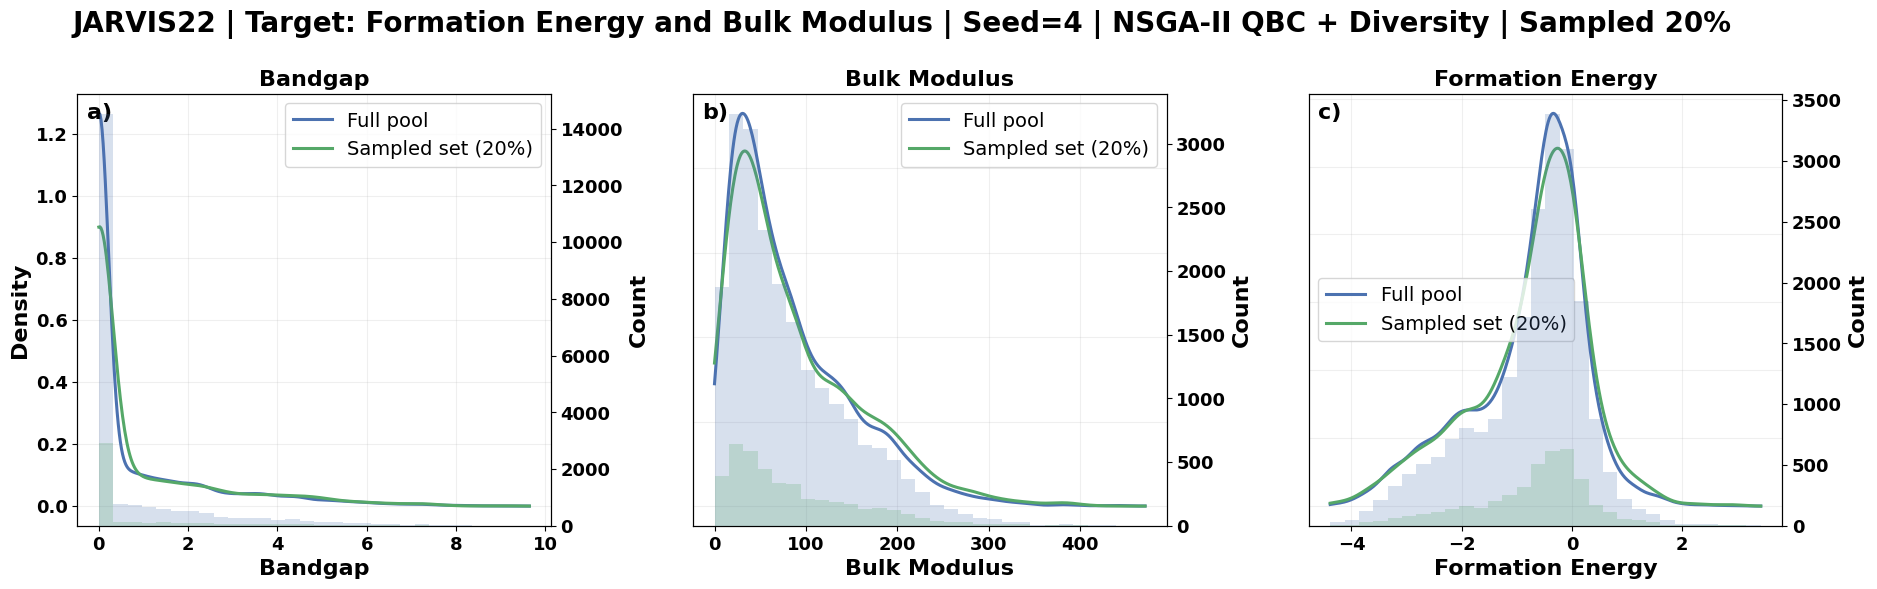

In [1]:
from __future__ import annotations

import os
from pathlib import Path
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# COLORS
# ============================================================
COLOR_POOL = "#4C72B0"          # blue
COLOR_SELECTED = "#DD8452"      # orange
COLOR_SELECTED_DIV = "#55A868"  # green

POLICY_EA_QBC_ONLY = "NSGA-II QBC"
POLICY_EA_QBC_DIVERSITY = "NSGA-II QBC + Diversity"


# ============================================================
# OUTPUT
# ============================================================
BASE_OUT_DIR = (
    r"c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto"
    r"\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\OutcomeDistributions_3Panel"
)

PCTS = [10, 20, 30, 40, 50, 60, 70, 80, 90]


# ============================================================
# PLOTTING CONFIG
# ============================================================
TITLE_FS = 16
LABEL_FS = 16
TICK_FS = 13
LEGEND_FS = 14
SUPTITLE_FS = 20

DIST_BINS = 30
HIST_ALPHA = 0.22
LINEWIDTH_DIST = 2.2


# ============================================================
# DATASETS + PATHS
# ============================================================
RAW_DATASET_PATHS: Dict[str, str] = {
    "mp21": r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\alldataRAW_mp21.csv",
    "mp18": r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\alldataRAW_mp18.csv",
    "jarvis18": r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\alldataRAW_jarvis18.csv",
    "jarvis22": r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\alldataRAW_jarvis22.csv",
}

SEEDS = range(5)

TARGET_OUTCOMES = [
    "bandgap_bulkmodulus",
    "bandgap_eform",
    "eform_bulk_modulus",
]

# ------------------------------------------------------------
# IMPORTANT:
# If your raw CSV uses slightly different column names,
# only edit this dictionary.
# ------------------------------------------------------------
PROPERTY_COLUMNS = {
    "bandgap": "bandgap",
    "bulk_modulus": "bulk_modulus",
    "e_form": "e_form",
}

PROPERTY_LABELS = {
    "bandgap": "Bandgap",
    "bulk_modulus": "Bulk Modulus",
    "e_form": "Formation Energy",
}


# ============================================================
# HELPERS
# ============================================================
def load_raw_data_with_orig_row(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["__orig_row"] = np.arange(len(df), dtype=int)
    return df


def load_train_indices_flexible(path_no_ext_or_with_ext: str) -> np.ndarray:
    candidates = [path_no_ext_or_with_ext]
    p = Path(path_no_ext_or_with_ext)
    if p.suffix == "":
        candidates += [str(p.with_suffix(".csv")), str(p.with_suffix(".txt"))]

    found = None
    for c in candidates:
        if Path(c).exists():
            found = c
            break

    if found is None:
        raise FileNotFoundError(f"Could not find indices file. Tried: {candidates}")

    found_path = Path(found)
    if found_path.suffix.lower() == ".csv":
        df = pd.read_csv(found)
        if "trainIndices" in df.columns:
            col = df["trainIndices"]
        else:
            col = df.iloc[:, 0]
        return col.dropna().astype(int).to_numpy()

    lines = found_path.read_text().strip().splitlines()
    vals: List[int] = []
    for ln in lines:
        s = ln.strip()
        if s:
            vals.append(int(s))
    return np.asarray(vals, dtype=int)


def make_pool_df_from_indices(df_raw: pd.DataFrame, indices: np.ndarray) -> pd.DataFrame:
    idx = pd.Index(indices.astype(int), dtype=int)
    n_raw = len(df_raw)
    bad = idx[(idx < 0) | (idx >= n_raw)]
    if len(bad) > 0:
        raise ValueError(
            f"Indices contain out-of-range rows (n_raw={n_raw}). "
            f"Example bad indices: {bad[:20].tolist()}"
        )
    return df_raw.loc[idx].copy().reset_index(drop=True)


def policy_first_k_orig_indices_in_pool(
    policy_order_orig: np.ndarray,
    pool_orig_set: set,
    k: int,
) -> Tuple[np.ndarray, np.ndarray]:
    first_k = policy_order_orig[:k].astype(int)
    present_mask = np.array([idx in pool_orig_set for idx in first_k], dtype=bool)
    present = first_k[present_mask]
    missing = first_k[~present_mask]
    return present, missing


def gaussian_density_curve(x: np.ndarray, grid: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if x.size == 0:
        return np.zeros_like(grid)

    if x.size == 1:
        sigma = 1e-6
    else:
        sigma = np.std(x, ddof=1)
        if sigma <= 1e-12:
            sigma = 1e-6

    n = x.size
    bw = 1.06 * sigma * (n ** (-1 / 5))
    if (not np.isfinite(bw)) or bw <= 1e-12:
        bw = max(sigma, 1e-6)

    diff = (grid[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * diff**2).sum(axis=1) / (n * bw * np.sqrt(2 * np.pi))
    return dens


def format_target_name(outcome: str) -> str:
    mapping = {
        "bandgap_bulkmodulus": "Bandgap and Bulk Modulus",
        "bandgap_eform": "Bandgap and Formation Energy",
        "eform_bulk_modulus": "Formation Energy and Bulk Modulus",
    }
    return mapping.get(outcome, outcome.replace("_", " ").title())


def ea_qbc_only_indices_path(dataset: str, outcome: str, seed: int) -> str:
    root = (
        r"c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto"
        r"\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\al\grow_2TargetsOnlyQBC"
    )
    return os.path.join(
        root,
        dataset,
        outcome,
        str(seed),
        f"{dataset}_{outcome}growing_EA_2obj_qbc_only{seed}_trainIndices.csv",
    )


def ea_qbc_diversity_indices_path(dataset: str, outcome: str, seed: int) -> str:
    root = (
        r"c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto"
        r"\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\al\grow_2TargetsDiversity"
    )
    return os.path.join(
        root,
        dataset,
        outcome,
        str(seed),
        f"{dataset}_{outcome}growing_EA_2obj_qbc_Diversity{seed}_trainIndices.csv",
    )


def get_numeric_values(df: pd.DataFrame, col: str) -> np.ndarray:
    if col not in df.columns:
        raise KeyError(
            f"Column '{col}' was not found in the raw data. "
            f"Available columns include: {df.columns[:30].tolist()} ..."
        )
    x = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
    return x[np.isfinite(x)]


def add_panel_letters(axes: List[plt.Axes]) -> None:
    letters = ["a)", "b)", "c)"]
    for ax, lab in zip(axes, letters):
        ax.text(
            0.02, 0.98, lab,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=TITLE_FS,
            fontweight="bold",
        )


def plot_one_distribution_panel(
    ax: plt.Axes,
    pool_vals: np.ndarray,
    sampled_vals: np.ndarray,
    title: str,
    sampled_label: str,
    sampled_color: str,
    show_ylabel: bool = True,
) -> None:
    pool_vals = np.asarray(pool_vals, dtype=float)
    sampled_vals = np.asarray(sampled_vals, dtype=float)

    all_x = np.concatenate([pool_vals, sampled_vals]) if (len(pool_vals) + len(sampled_vals)) > 0 else np.array([0.0, 1.0])
    xmin, xmax = np.min(all_x), np.max(all_x)
    if np.isclose(xmin, xmax):
        xmin -= 1.0
        xmax += 1.0

    bins = np.linspace(xmin, xmax, DIST_BINS + 1)
    grid = np.linspace(xmin, xmax, 400)

    ax_count = ax.twinx()

    # Histograms on count axis
    ax_count.hist(
        pool_vals,
        bins=bins,
        alpha=HIST_ALPHA,
        color=COLOR_POOL,
        histtype="stepfilled",
    )
    ax_count.hist(
        sampled_vals,
        bins=bins,
        alpha=HIST_ALPHA,
        color=sampled_color,
        histtype="stepfilled",
    )

    # Smooth density curves on density axis
    dens_pool = gaussian_density_curve(pool_vals, grid)
    dens_sampled = gaussian_density_curve(sampled_vals, grid)

    ax.plot(
        grid, dens_pool,
        color=COLOR_POOL,
        linewidth=LINEWIDTH_DIST,
        label="Full pool",
    )
    ax.plot(
        grid, dens_sampled,
        color=sampled_color,
        linewidth=LINEWIDTH_DIST,
        label=sampled_label,
    )

    ax.set_title(title, fontsize=TITLE_FS, fontweight="bold")
    ax.set_xlabel(title, fontsize=LABEL_FS, fontweight="bold")

    if show_ylabel:
        ax.set_ylabel("Density", fontsize=LABEL_FS, fontweight="bold")
    else:
        ax.set_ylabel("")

    ax_count.set_ylabel("Count", fontsize=LABEL_FS, fontweight="bold")

    ax.tick_params(axis="both", labelsize=TICK_FS)
    ax_count.tick_params(axis="y", labelsize=TICK_FS)

    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    for lbl in ax_count.get_yticklabels():
        lbl.set_fontweight("bold")

    if not show_ylabel:
        ax.tick_params(axis="y", left=False, labelleft=False)

    ax.grid(alpha=0.2)

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax_count.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=LEGEND_FS, loc="best")


def plot_three_outcome_distributions(
    df_pool: pd.DataFrame,
    df_sampled: pd.DataFrame,
    dataset: str,
    target_outcome: str,
    seed: int,
    pct: int,
    policy_label: str,
    sampled_color: str,
    out_path: str,
) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    properties = ["bandgap", "bulk_modulus", "e_form"]

    for i, prop in enumerate(properties):
        col = PROPERTY_COLUMNS[prop]
        label = PROPERTY_LABELS[prop]

        pool_vals = get_numeric_values(df_pool, col)
        sampled_vals = get_numeric_values(df_sampled, col)

        plot_one_distribution_panel(
            ax=axes[i],
            pool_vals=pool_vals,
            sampled_vals=sampled_vals,
            title=label,
            sampled_label=f"Sampled set ({pct}%)",
            sampled_color=sampled_color,
            show_ylabel=(i == 0),
        )

    add_panel_letters(list(axes))

    dataset_str = dataset.upper()
    target_str = format_target_name(target_outcome)

    fig.subplots_adjust(top=0.83, wspace=0.30)
    fig.suptitle(
        f"{dataset_str} | Target: {target_str} | Seed={seed} | {policy_label} | Sampled {pct}%",
        fontsize=SUPTITLE_FS,
        fontweight="bold",
        y=0.97,
    )

    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


# ============================================================
# MAIN
# ============================================================
def main() -> None:
    os.makedirs(BASE_OUT_DIR, exist_ok=True)

    for dataset, raw_path in RAW_DATASET_PATHS.items():
        print("=" * 100)
        print(f"[DATASET] {dataset}")
        print(f"  RAW: {raw_path}")

        df_raw = load_raw_data_with_orig_row(raw_path)

        dataset_out_dir = os.path.join(BASE_OUT_DIR, dataset)
        os.makedirs(dataset_out_dir, exist_ok=True)

        for outcome in TARGET_OUTCOMES:
            outcome_out_dir = os.path.join(dataset_out_dir, outcome)
            os.makedirs(outcome_out_dir, exist_ok=True)

            for seed in SEEDS:
                seed_out_dir = os.path.join(outcome_out_dir, f"seed_{seed}")
                os.makedirs(seed_out_dir, exist_ok=True)

                # -----------------------------
                # Load policy orders
                # -----------------------------
                ea_only_path = ea_qbc_only_indices_path(dataset, outcome, seed)
                ea_div_path = ea_qbc_diversity_indices_path(dataset, outcome, seed)

                ea_only_order = load_train_indices_flexible(ea_only_path)
                ea_div_order = load_train_indices_flexible(ea_div_path)

                # -----------------------------
                # Build pool dfs
                # -----------------------------
                df_pool_ea_only = make_pool_df_from_indices(df_raw, ea_only_order)
                df_pool_ea_div = make_pool_df_from_indices(df_raw, ea_div_order)

                set_ea_only = set(df_pool_ea_only["__orig_row"].astype(int).tolist())
                set_ea_div = set(df_pool_ea_div["__orig_row"].astype(int).tolist())

                n_ea_only = len(df_pool_ea_only)
                n_ea_div = len(df_pool_ea_div)

                # -----------------------------
                # Loop over iterations
                # -----------------------------
                for pct in PCTS:
                    # ===== Policy: NSGA-II QBC =====
                    k1 = int(np.ceil((pct / 100.0) * n_ea_only))
                    present1, missing1 = policy_first_k_orig_indices_in_pool(ea_only_order, set_ea_only, k1)

                    if len(missing1) > 0:
                        print(
                            f"[WARN] {dataset} | {outcome} | seed={seed} | "
                            f"{POLICY_EA_QBC_ONLY} | {pct}% -> {len(missing1)} missing"
                        )

                    df_sampled1 = df_pool_ea_only[
                        df_pool_ea_only["__orig_row"].isin(present1)
                    ].copy()

                    out_plot1 = os.path.join(
                        seed_out_dir,
                        f"OUTCOME_DISTRIBUTIONS_{dataset}_{outcome}_seed{seed}_EA_QBC_ONLY_{pct}pct.png"
                    )

                    plot_three_outcome_distributions(
                        df_pool=df_pool_ea_only,
                        df_sampled=df_sampled1,
                        dataset=dataset,
                        target_outcome=outcome,
                        seed=seed,
                        pct=pct,
                        policy_label=POLICY_EA_QBC_ONLY,
                        sampled_color=COLOR_SELECTED,
                        out_path=out_plot1,
                    )

                    print(f"[OK] Saved: {out_plot1}")

                    # ===== Policy: NSGA-II QBC + Diversity =====
                    k2 = int(np.ceil((pct / 100.0) * n_ea_div))
                    present2, missing2 = policy_first_k_orig_indices_in_pool(ea_div_order, set_ea_div, k2)

                    if len(missing2) > 0:
                        print(
                            f"[WARN] {dataset} | {outcome} | seed={seed} | "
                            f"{POLICY_EA_QBC_DIVERSITY} | {pct}% -> {len(missing2)} missing"
                        )

                    df_sampled2 = df_pool_ea_div[
                        df_pool_ea_div["__orig_row"].isin(present2)
                    ].copy()

                    out_plot2 = os.path.join(
                        seed_out_dir,
                        f"OUTCOME_DISTRIBUTIONS_{dataset}_{outcome}_seed{seed}_EA_QBC_DIVERSITY_{pct}pct.png"
                    )

                    plot_three_outcome_distributions(
                        df_pool=df_pool_ea_div,
                        df_sampled=df_sampled2,
                        dataset=dataset,
                        target_outcome=outcome,
                        seed=seed,
                        pct=pct,
                        policy_label=POLICY_EA_QBC_DIVERSITY,
                        sampled_color=COLOR_SELECTED_DIV,
                        out_path=out_plot2,
                    )

                    print(f"[OK] Saved: {out_plot2}")
                    print("-" * 90)


if __name__ == "__main__":
    main()

[DATASET] mp21
  RAW: C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\alldataRAW_mp21.csv
[OK] Saved: c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\OutcomeDistributions_3Panel_CombinedPolicies\mp21\bandgap_bulkmodulus\seed_0\OUTCOME_DISTRIBUTIONS_COMBINED_mp21_bandgap_bulkmodulus_seed0_10pct.png
------------------------------------------------------------------------------------------
[OK] Saved: c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\OutcomeDistributions_3Panel_CombinedPolicies\mp21\bandgap_bulkmodulus\seed_0\OUTCOME_DISTRIBUTIONS_COMBINED_mp21_bandgap_bulkmodulus_seed0_20pct.png
------------------------------------------------------------------------------------------
[OK] Saved: c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD T

KeyboardInterrupt: 

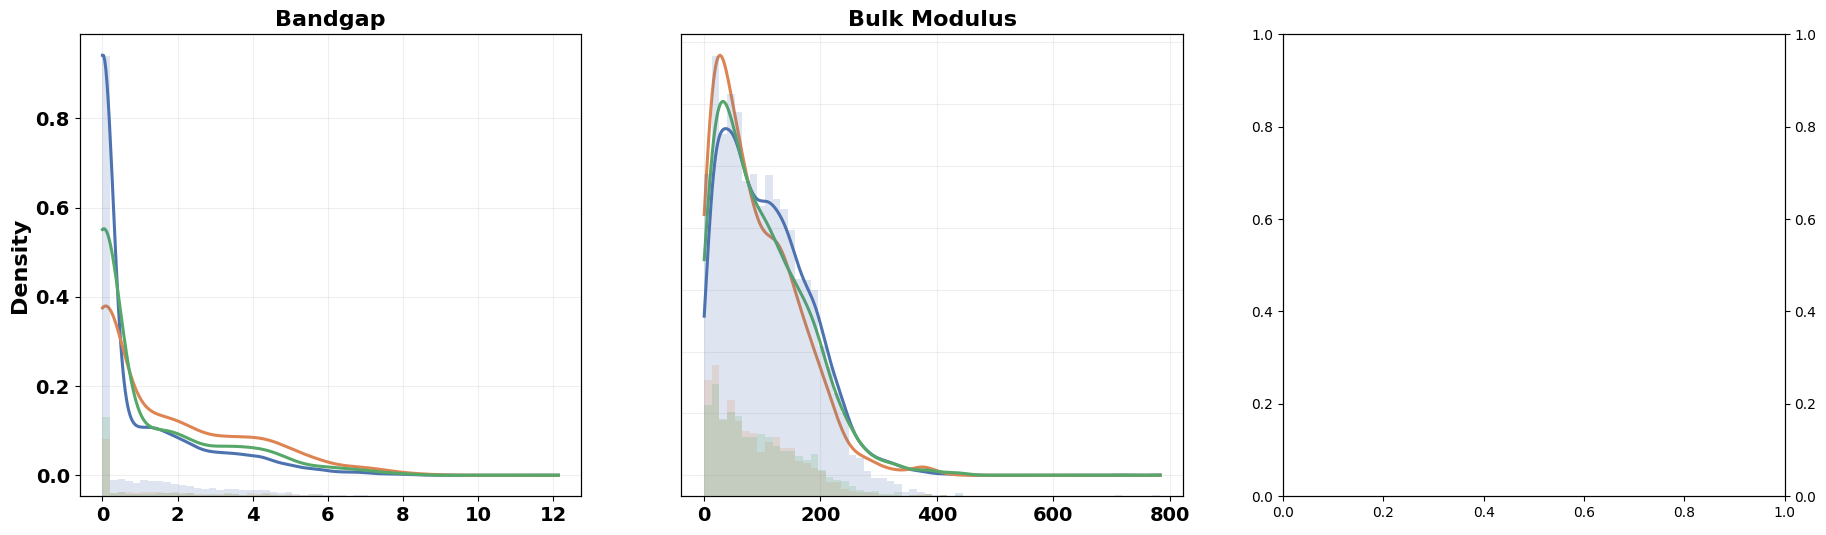

In [1]:
from __future__ import annotations

import os
from pathlib import Path
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ============================================================
# COLORS
# ============================================================
COLOR_POOL = "#4C72B0"          # blue
COLOR_QBC = "#DD8452"           # orange
COLOR_QBC_DIV = "#55A868"       # green

POLICY_EA_QBC_ONLY = "NSGA-II QBC"
POLICY_EA_QBC_DIVERSITY = "NSGA-II QBC + Diversity"


# ============================================================
# OUTPUT
# ============================================================
BASE_OUT_DIR = (
    r"c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto"
    r"\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\OutcomeDistributions_3Panel_CombinedPolicies"
)

PCTS = [10, 20, 30, 40, 50, 60, 70, 80, 90]


# ============================================================
# PLOTTING CONFIG
# ============================================================
TITLE_FS = 16
LABEL_FS = 16
TICK_FS = 14
LEGEND_FS = 14
SUPTITLE_FS = 20

DIST_BINS = 60
HIST_ALPHA = 0.18
LINEWIDTH_DIST = 2.2


# ============================================================
# DATASETS + PATHS
# ============================================================
RAW_DATASET_PATHS: Dict[str, str] = {
    "mp21": r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\alldataRAW_mp21.csv",
    "mp18": r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\alldataRAW_mp18.csv",
    "jarvis18": r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\alldataRAW_jarvis18.csv",
    "jarvis22": r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\alldataRAW_jarvis22.csv",
}

SEEDS = range(5)

TARGET_OUTCOMES = [
    "bandgap_bulkmodulus",
    "bandgap_eform",
    "eform_bulk_modulus",
]

# ------------------------------------------------------------
# Edit only this if the raw column names differ
# ------------------------------------------------------------
PROPERTY_COLUMNS = {
    "bandgap": "bandgap",
    "bulk_modulus": "bulk_modulus",
    "e_form": "e_form",
}

PROPERTY_LABELS = {
    "bandgap": "Bandgap",
    "bulk_modulus": "Bulk Modulus",
    "e_form": "Formation Energy",
}


# ============================================================
# HELPERS
# ============================================================
def load_raw_data_with_orig_row(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["__orig_row"] = np.arange(len(df), dtype=int)
    return df


def load_train_indices_flexible(path_no_ext_or_with_ext: str) -> np.ndarray:
    candidates = [path_no_ext_or_with_ext]
    p = Path(path_no_ext_or_with_ext)
    if p.suffix == "":
        candidates += [str(p.with_suffix(".csv")), str(p.with_suffix(".txt"))]

    found = None
    for c in candidates:
        if Path(c).exists():
            found = c
            break

    if found is None:
        raise FileNotFoundError(f"Could not find indices file. Tried: {candidates}")

    found_path = Path(found)
    if found_path.suffix.lower() == ".csv":
        df = pd.read_csv(found)
        if "trainIndices" in df.columns:
            col = df["trainIndices"]
        else:
            col = df.iloc[:, 0]
        return col.dropna().astype(int).to_numpy()

    lines = found_path.read_text().strip().splitlines()
    vals: List[int] = []
    for ln in lines:
        s = ln.strip()
        if s:
            vals.append(int(s))
    return np.asarray(vals, dtype=int)


def make_pool_df_from_indices(df_raw: pd.DataFrame, indices: np.ndarray) -> pd.DataFrame:
    idx = pd.Index(indices.astype(int), dtype=int)
    n_raw = len(df_raw)
    bad = idx[(idx < 0) | (idx >= n_raw)]
    if len(bad) > 0:
        raise ValueError(
            f"Indices contain out-of-range rows (n_raw={n_raw}). "
            f"Example bad indices: {bad[:20].tolist()}"
        )
    return df_raw.loc[idx].copy().reset_index(drop=True)


def policy_first_k_orig_indices_in_pool(
    policy_order_orig: np.ndarray,
    pool_orig_set: set,
    k: int,
) -> Tuple[np.ndarray, np.ndarray]:
    first_k = policy_order_orig[:k].astype(int)
    present_mask = np.array([idx in pool_orig_set for idx in first_k], dtype=bool)
    present = first_k[present_mask]
    missing = first_k[~present_mask]
    return present, missing


def gaussian_density_curve(x: np.ndarray, grid: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if x.size == 0:
        return np.zeros_like(grid)

    if x.size == 1:
        sigma = 1e-6
    else:
        sigma = np.std(x, ddof=1)
        if sigma <= 1e-12:
            sigma = 1e-6

    n = x.size
    bw = 1.06 * sigma * (n ** (-1 / 5))
    if (not np.isfinite(bw)) or bw <= 1e-12:
        bw = max(sigma, 1e-6)

    diff = (grid[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * diff**2).sum(axis=1) / (n * bw * np.sqrt(2 * np.pi))
    return dens


def format_target_name(outcome: str) -> str:
    mapping = {
        "bandgap_bulkmodulus": "Bandgap and Bulk Modulus",
        "bandgap_eform": "Bandgap and Formation Energy",
        "eform_bulk_modulus": "Formation Energy and Bulk Modulus",
    }
    return mapping.get(outcome, outcome.replace("_", " ").title())


def ea_qbc_only_indices_path(dataset: str, outcome: str, seed: int) -> str:
    root = (
        r"c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto"
        r"\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\al\grow_2TargetsOnlyQBC"
    )
    return os.path.join(
        root,
        dataset,
        outcome,
        str(seed),
        f"{dataset}_{outcome}growing_EA_2obj_qbc_only{seed}_trainIndices.csv",
    )


def ea_qbc_diversity_indices_path(dataset: str, outcome: str, seed: int) -> str:
    root = (
        r"c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto"
        r"\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\al\grow_2TargetsDiversity"
    )
    return os.path.join(
        root,
        dataset,
        outcome,
        str(seed),
        f"{dataset}_{outcome}growing_EA_2obj_qbc_Diversity{seed}_trainIndices.csv",
    )


def get_numeric_values(df: pd.DataFrame, col: str) -> np.ndarray:
    if col not in df.columns:
        raise KeyError(
            f"Column '{col}' was not found in the raw data. "
            f"Available columns include: {df.columns[:30].tolist()} ..."
        )
    x = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
    return x[np.isfinite(x)]


def add_panel_letters(axes: List[plt.Axes]) -> None:
    letters = ["a)", "b)", "c)"]
    for ax, lab in zip(axes, letters):
        ax.text(0.0, 1.02, lab,   # <-- key change
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=TITLE_FS,
        fontweight="bold",)


def plot_one_distribution_panel_combined(
    ax: plt.Axes,
    pool_vals: np.ndarray,
    qbc_vals: np.ndarray,
    div_vals: np.ndarray,
    title: str,
    show_left_ylabel: bool = True,
    show_right_ylabel: bool = True,
) -> None:
    pool_vals = np.asarray(pool_vals, dtype=float)
    qbc_vals = np.asarray(qbc_vals, dtype=float)
    div_vals = np.asarray(div_vals, dtype=float)

    all_x = np.concatenate([pool_vals, qbc_vals, div_vals])
    all_x = all_x[np.isfinite(all_x)]

    if all_x.size == 0:
        all_x = np.array([0.0, 1.0])

    xmin, xmax = np.min(all_x), np.max(all_x)
    if np.isclose(xmin, xmax):
        xmin -= 1.0
        xmax += 1.0

    bins = np.linspace(xmin, xmax, DIST_BINS + 1)
    grid = np.linspace(xmin, xmax, 400)

    ax_count = ax.twinx()

    # Histograms
    ax_count.hist(
        pool_vals,
        bins=bins,
        alpha=HIST_ALPHA,
        color=COLOR_POOL,
        histtype="stepfilled",
    )
    ax_count.hist(
        qbc_vals,
        bins=bins,
        alpha=HIST_ALPHA,
        color=COLOR_QBC,
        histtype="stepfilled",
    )
    ax_count.hist(
        div_vals,
        bins=bins,
        alpha=HIST_ALPHA,
        color=COLOR_QBC_DIV,
        histtype="stepfilled",
    )

    # Density curves
    dens_pool = gaussian_density_curve(pool_vals, grid)
    dens_qbc = gaussian_density_curve(qbc_vals, grid)
    dens_div = gaussian_density_curve(div_vals, grid)

    ax.plot(grid, dens_pool, color=COLOR_POOL, linewidth=LINEWIDTH_DIST)
    ax.plot(grid, dens_qbc, color=COLOR_QBC, linewidth=LINEWIDTH_DIST)
    ax.plot(grid, dens_div, color=COLOR_QBC_DIV, linewidth=LINEWIDTH_DIST)

    ax.set_title(title, fontsize=TITLE_FS, fontweight="bold")
   # ax.set_xlabel(title, fontsize=LABEL_FS, fontweight="bold")

    if show_left_ylabel:
        ax.set_ylabel("Density", fontsize=LABEL_FS, fontweight="bold")
    else:
        ax.set_ylabel("")
        ax.tick_params(axis="y", left=False, labelleft=False)

    if show_right_ylabel:
        ax_count.set_ylabel("Count", fontsize=LABEL_FS, fontweight="bold")
    else:
        ax_count.set_ylabel("")
        ax_count.tick_params(axis="y", right=False, labelright=False)

    ax.tick_params(axis="both", labelsize=TICK_FS)
    ax_count.tick_params(axis="y", labelsize=TICK_FS)

    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
    for lbl in ax_count.get_yticklabels():
        lbl.set_fontweight("bold")

    ax.grid(alpha=0.2)


def add_common_legend_below(fig: plt.Figure) -> None:
    handles = [
        Patch(facecolor=COLOR_POOL, edgecolor=COLOR_POOL, alpha=HIST_ALPHA, label="Full pool"),
        Patch(facecolor=COLOR_QBC, edgecolor=COLOR_QBC, alpha=HIST_ALPHA, label="NSGA-II QBC"),
        Patch(facecolor=COLOR_QBC_DIV, edgecolor=COLOR_QBC_DIV, alpha=HIST_ALPHA, label="NSGA-II QBC + Diversity"),
        Line2D([0], [0], color=COLOR_POOL, lw=LINEWIDTH_DIST, label="Full pool density"),
        Line2D([0], [0], color=COLOR_QBC, lw=LINEWIDTH_DIST, label="NSGA-II QBC density"),
        Line2D([0], [0], color=COLOR_QBC_DIV, lw=LINEWIDTH_DIST, label="NSGA-II QBC + Diversity density"),
    ]

    legend = fig.legend(
        handles=handles,
        loc="lower center",
        ncol=3,
        fontsize=LEGEND_FS,
        frameon=True,
        fancybox=True,
        bbox_to_anchor=(0.5, 0.02),
    )
    legend.get_frame().set_alpha(1.0)


def plot_three_outcome_distributions_combined(
    df_pool_qbc: pd.DataFrame,
    df_sampled_qbc: pd.DataFrame,
    df_pool_div: pd.DataFrame,
    df_sampled_div: pd.DataFrame,
    dataset: str,
    target_outcome: str,
    seed: int,
    pct: int,
    out_path: str,
) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))

    properties = ["bandgap", "bulk_modulus", "e_form"]

    for i, prop in enumerate(properties):
        col = PROPERTY_COLUMNS[prop]
        label = PROPERTY_LABELS[prop]

        pool_vals = get_numeric_values(df_pool_qbc, col)
        qbc_vals = get_numeric_values(df_sampled_qbc, col)
        div_vals = get_numeric_values(df_sampled_div, col)

        plot_one_distribution_panel_combined(
            ax=axes[i],
            pool_vals=pool_vals,
            qbc_vals=qbc_vals,
            div_vals=div_vals,
            title=label,
            show_left_ylabel=(i == 0),
            show_right_ylabel=(i == 2),
        )

    add_panel_letters(list(axes))
    add_common_legend_below(fig)

    dataset_str = dataset.upper()
    target_str = format_target_name(target_outcome)

    fig.subplots_adjust(
        top=0.82,
        bottom=0.23,
        wspace=0.28,
    )

    fig.suptitle(
        f"{dataset_str} | Target: {target_str} | Seed={seed} | Sampled {pct}%",
        fontsize=SUPTITLE_FS,
        fontweight="bold",
        y=0.96,
    )

    fig.savefig(out_path, dpi=100, bbox_inches="tight")
    plt.close(fig)


# ============================================================
# MAIN
# ============================================================
def main() -> None:
    os.makedirs(BASE_OUT_DIR, exist_ok=True)

    for dataset, raw_path in RAW_DATASET_PATHS.items():
        print("=" * 100)
        print(f"[DATASET] {dataset}")
        print(f"  RAW: {raw_path}")

        df_raw = load_raw_data_with_orig_row(raw_path)

        dataset_out_dir = os.path.join(BASE_OUT_DIR, dataset)
        os.makedirs(dataset_out_dir, exist_ok=True)

        for outcome in TARGET_OUTCOMES:
            outcome_out_dir = os.path.join(dataset_out_dir, outcome)
            os.makedirs(outcome_out_dir, exist_ok=True)

            for seed in SEEDS:
                seed_out_dir = os.path.join(outcome_out_dir, f"seed_{seed}")
                os.makedirs(seed_out_dir, exist_ok=True)

                ea_only_path = ea_qbc_only_indices_path(dataset, outcome, seed)
                ea_div_path = ea_qbc_diversity_indices_path(dataset, outcome, seed)

                ea_only_order = load_train_indices_flexible(ea_only_path)
                ea_div_order = load_train_indices_flexible(ea_div_path)

                df_pool_qbc = make_pool_df_from_indices(df_raw, ea_only_order)
                df_pool_div = make_pool_df_from_indices(df_raw, ea_div_order)

                set_qbc = set(df_pool_qbc["__orig_row"].astype(int).tolist())
                set_div = set(df_pool_div["__orig_row"].astype(int).tolist())

                n_qbc = len(df_pool_qbc)
                n_div = len(df_pool_div)

                for pct in PCTS:
                    k_qbc = int(np.ceil((pct / 100.0) * n_qbc))
                    present_qbc, missing_qbc = policy_first_k_orig_indices_in_pool(ea_only_order, set_qbc, k_qbc)

                    if len(missing_qbc) > 0:
                        print(
                            f"[WARN] {dataset} | {outcome} | seed={seed} | "
                            f"{POLICY_EA_QBC_ONLY} | {pct}% -> {len(missing_qbc)} missing"
                        )

                    df_sampled_qbc = df_pool_qbc[
                        df_pool_qbc["__orig_row"].isin(present_qbc)
                    ].copy()

                    k_div = int(np.ceil((pct / 100.0) * n_div))
                    present_div, missing_div = policy_first_k_orig_indices_in_pool(ea_div_order, set_div, k_div)

                    if len(missing_div) > 0:
                        print(
                            f"[WARN] {dataset} | {outcome} | seed={seed} | "
                            f"{POLICY_EA_QBC_DIVERSITY} | {pct}% -> {len(missing_div)} missing"
                        )

                    df_sampled_div = df_pool_div[
                        df_pool_div["__orig_row"].isin(present_div)
                    ].copy()

                    out_plot = os.path.join(
                        seed_out_dir,
                        f"OUTCOME_DISTRIBUTIONS_COMBINED_{dataset}_{outcome}_seed{seed}_{pct}pct.png"
                    )

                    plot_three_outcome_distributions_combined(
                        df_pool_qbc=df_pool_qbc,
                        df_sampled_qbc=df_sampled_qbc,
                        df_pool_div=df_pool_div,
                        df_sampled_div=df_sampled_div,
                        dataset=dataset,
                        target_outcome=outcome,
                        seed=seed,
                        pct=pct,
                        out_path=out_plot,
                    )

                    print(f"[OK] Saved: {out_plot}")
                    print("-" * 90)


if __name__ == "__main__":
    main()

In [2]:
from __future__ import annotations

import os
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# ============================================================
# OUTPUT
# ============================================================
BASE_OUT_DIR = (
    r"c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto"
    r"\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\PCA_SelectedPool_OutcomeHeatmaps"
)


# ============================================================
# PLOTTING CONFIG
# ============================================================
TITLE_FS = 16
LABEL_FS = 16
TICK_FS = 14
SUPTITLE_FS = 20

SCATTER_SIZE = 24
SCATTER_ALPHA = 0.90
CMAP = "viridis"


# ============================================================
# DATASETS + PATHS
# ============================================================
RAW_DATASET_PATHS: Dict[str, str] = {
    "mp21": r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\alldataRAW_mp21.csv",
    "mp18": r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\alldataRAW_mp18.csv",
    "jarvis18": r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\alldataRAW_jarvis18.csv",
    "jarvis22": r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\alldataRAW_jarvis22.csv",
}

TARGET_OUTCOMES = [
    "bandgap_bulkmodulus",
    "bandgap_eform",
    "eform_bulk_modulus",
]

# ------------------------------------------------------------
# Choose only one policy and one seed here
# ------------------------------------------------------------
REFERENCE_SEED = 0

# Options:
#   "qbc_only"
#   "qbc_diversity"
SELECTED_POLICY = "qbc_only"


# ============================================================
# PROPERTY COLUMNS
# ============================================================
PROPERTY_COLUMNS = {
    "bandgap": "bandgap",
    "bulk_modulus": "bulk_modulus",
    "e_form": "e_form",
}

PROPERTY_LABELS = {
    "bandgap": "Bandgap",
    "bulk_modulus": "Bulk Modulus",
    "e_form": "Formation Energy",
}


# ============================================================
# HELPERS
# ============================================================
def load_raw_data_with_orig_row(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["__orig_row"] = np.arange(len(df), dtype=int)
    return df


def load_train_indices_flexible(path_no_ext_or_with_ext: str) -> np.ndarray:
    candidates = [path_no_ext_or_with_ext]
    p = Path(path_no_ext_or_with_ext)

    if p.suffix == "":
        candidates += [str(p.with_suffix(".csv")), str(p.with_suffix(".txt"))]

    found = None
    for c in candidates:
        if Path(c).exists():
            found = c
            break

    if found is None:
        raise FileNotFoundError(f"Could not find indices file. Tried: {candidates}")

    found_path = Path(found)

    if found_path.suffix.lower() == ".csv":
        df = pd.read_csv(found)
        if "trainIndices" in df.columns:
            col = df["trainIndices"]
        else:
            col = df.iloc[:, 0]
        return col.dropna().astype(int).to_numpy()

    lines = found_path.read_text().strip().splitlines()
    vals: List[int] = []
    for ln in lines:
        s = ln.strip()
        if s:
            vals.append(int(s))
    return np.asarray(vals, dtype=int)


def extract_rows_from_raw(df_raw: pd.DataFrame, indices: np.ndarray) -> pd.DataFrame:
    idx = pd.Index(indices.astype(int), dtype=int)
    n_raw = len(df_raw)

    bad = idx[(idx < 0) | (idx >= n_raw)]
    if len(bad) > 0:
        raise ValueError(
            f"Indices contain out-of-range rows (n_raw={n_raw}). "
            f"Example bad indices: {bad[:20].tolist()}"
        )

    return df_raw.loc[idx].copy().reset_index(drop=True)


def format_target_name(outcome: str) -> str:
    mapping = {
        "bandgap_bulkmodulus": "Bandgap and Bulk Modulus",
        "bandgap_eform": "Bandgap and Formation Energy",
        "eform_bulk_modulus": "Formation Energy and Bulk Modulus",
    }
    return mapping.get(outcome, outcome.replace("_", " ").title())


def qbc_only_indices_path(dataset: str, outcome: str, seed: int) -> str:
    root = (
        r"c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto"
        r"\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\al\grow_2TargetsOnlyQBC"
    )
    return os.path.join(
        root,
        dataset,
        outcome,
        str(seed),
        f"{dataset}_{outcome}growing_EA_2obj_qbc_only{seed}_trainIndices.csv",
    )


def qbc_diversity_indices_path(dataset: str, outcome: str, seed: int) -> str:
    root = (
        r"c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto"
        r"\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\al\grow_2TargetsDiversity"
    )
    return os.path.join(
        root,
        dataset,
        outcome,
        str(seed),
        f"{dataset}_{outcome}growing_EA_2obj_qbc_Diversity{seed}_trainIndices.csv",
    )


def selected_indices_path(dataset: str, outcome: str, seed: int) -> str:
    if SELECTED_POLICY == "qbc_only":
        return qbc_only_indices_path(dataset, outcome, seed)
    elif SELECTED_POLICY == "qbc_diversity":
        return qbc_diversity_indices_path(dataset, outcome, seed)
    else:
        raise ValueError(
            f"Unknown SELECTED_POLICY='{SELECTED_POLICY}'. "
            f"Use 'qbc_only' or 'qbc_diversity'."
        )


def add_panel_letters(axes: List[plt.Axes]) -> None:
    letters = ["a)", "b)", "c)"]
    for ax, lab in zip(axes, letters):
        ax.text(
            0.0, 1.02,
            lab,
            transform=ax.transAxes,
            ha="left",
            va="bottom",
            fontsize=TITLE_FS,
            fontweight="bold",
        )


def get_feature_columns(df: pd.DataFrame) -> List[str]:
    excluded = {
        "__orig_row",
        PROPERTY_COLUMNS["bandgap"],
        PROPERTY_COLUMNS["bulk_modulus"],
        PROPERTY_COLUMNS["e_form"],
    }

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in excluded]

    if len(feature_cols) == 0:
        raise ValueError("No numeric feature columns were found for PCA.")

    return feature_cols


# If you prefer the last 273 descriptor columns, replace the function above with:
# def get_feature_columns(df: pd.DataFrame) -> List[str]:
#     return df.columns[-273:].tolist()


def compute_pca_coordinates(df: pd.DataFrame) -> pd.DataFrame:
    feature_cols = get_feature_columns(df)

    X = df[feature_cols].copy()
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.apply(lambda col: col.fillna(col.median()), axis=0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2)
    coords = pca.fit_transform(X_scaled)

    out = df.copy()
    out["PC1"] = coords[:, 0]
    out["PC2"] = coords[:, 1]
    return out


def make_vmin_vmax(df: pd.DataFrame, col: str) -> Tuple[float, float]:
    vals = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]

    if vals.size == 0:
        return 0.0, 1.0

    vmin = np.percentile(vals, 5)
    vmax = np.percentile(vals, 95)

    if np.isclose(vmin, vmax):
        vmin = np.min(vals)
        vmax = np.max(vals)
        if np.isclose(vmin, vmax):
            vmin -= 1.0
            vmax += 1.0

    return float(vmin), float(vmax)


def style_axis(ax: plt.Axes, show_ylabel: bool = True) -> None:
    ax.set_xlabel("PC1", fontsize=LABEL_FS, fontweight="bold")
    if show_ylabel:
        ax.set_ylabel("PC2", fontsize=LABEL_FS, fontweight="bold")
    else:
        ax.set_ylabel("")

    ax.tick_params(axis="both", labelsize=TICK_FS)

    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")

    ax.grid(alpha=0.2)


def plot_one_pca_panel(
    ax: plt.Axes,
    df: pd.DataFrame,
    value_col: str,
    title: str,
    vmin: float,
    vmax: float,
    show_ylabel: bool = True,
):
    vals = pd.to_numeric(df[value_col], errors="coerce")
    mask = np.isfinite(df["PC1"]) & np.isfinite(df["PC2"]) & np.isfinite(vals)

    sc = ax.scatter(
        df.loc[mask, "PC1"],
        df.loc[mask, "PC2"],
        c=vals.loc[mask],
        cmap=CMAP,
        s=SCATTER_SIZE,
        alpha=SCATTER_ALPHA,
        vmin=vmin,
        vmax=vmax,
        edgecolors="none",
    )

    ax.set_title(title, fontsize=TITLE_FS, fontweight="bold")
    style_axis(ax, show_ylabel=show_ylabel)
    return sc


def plot_three_outcome_pca_heatmaps(
    df_selected: pd.DataFrame,
    dataset: str,
    target_outcome: str,
    out_path: str,
) -> None:
    df_plot = compute_pca_coordinates(df_selected)

    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    properties = ["bandgap", "bulk_modulus", "e_form"]

    for i, prop in enumerate(properties):
        col = PROPERTY_COLUMNS[prop]
        label = PROPERTY_LABELS[prop]
        vmin, vmax = make_vmin_vmax(df_plot, col)

        sc = plot_one_pca_panel(
            ax=axes[i],
            df=df_plot,
            value_col=col,
            title=label,
            vmin=vmin,
            vmax=vmax,
            show_ylabel=(i == 0),
        )

        cbar = fig.colorbar(sc, ax=axes[i], fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=TICK_FS)
        for lbl in cbar.ax.get_yticklabels():
            lbl.set_fontweight("bold")

    add_panel_letters(list(axes))

    fig.subplots_adjust(
        top=0.82,
        bottom=0.14,
        wspace=0.30,
    )

    fig.suptitle(
        f"{dataset.upper()}",
        fontsize=SUPTITLE_FS,
        fontweight="bold",
        y=0.96,
    )

    fig.savefig(out_path, dpi=100, bbox_inches="tight")
    plt.close(fig)


# ============================================================
# MAIN
# ============================================================
def main() -> None:
    os.makedirs(BASE_OUT_DIR, exist_ok=True)

    for dataset, raw_path in RAW_DATASET_PATHS.items():
        print("=" * 100)
        print(f"[DATASET] {dataset}")
        print(f"  RAW: {raw_path}")

        df_raw = load_raw_data_with_orig_row(raw_path)

        dataset_out_dir = os.path.join(BASE_OUT_DIR, dataset)
        os.makedirs(dataset_out_dir, exist_ok=True)

        for outcome in TARGET_OUTCOMES:
            idx_path = selected_indices_path(dataset, outcome, REFERENCE_SEED)
            indices = load_train_indices_flexible(idx_path)
            df_selected = extract_rows_from_raw(df_raw, indices)

            out_plot = os.path.join(
                dataset_out_dir,
                f"PCA_HEATMAPS_SELECTEDROWS_{dataset}_{outcome}.png"
            )

            plot_three_outcome_pca_heatmaps(
                df_selected=df_selected,
                dataset=dataset,
                target_outcome=outcome,
                out_path=out_plot,
            )

            print(f"[OK] Saved: {out_plot}")


if __name__ == "__main__":
    main()

[DATASET] mp21
  RAW: C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\alldataRAW_mp21.csv
[OK] Saved: c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\PCA_SelectedPool_OutcomeHeatmaps\mp21\PCA_HEATMAPS_SELECTEDROWS_mp21_bandgap_bulkmodulus.png
[OK] Saved: c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\PCA_SelectedPool_OutcomeHeatmaps\mp21\PCA_HEATMAPS_SELECTEDROWS_mp21_bandgap_eform.png
[OK] Saved: c:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\PCA_SelectedPool_OutcomeHeatmaps\mp21\PCA_HEATMAPS_SELECTEDROWS_mp21_eform_bulk_modulus.png
[DATASET] mp18
  RAW: C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\alldataR

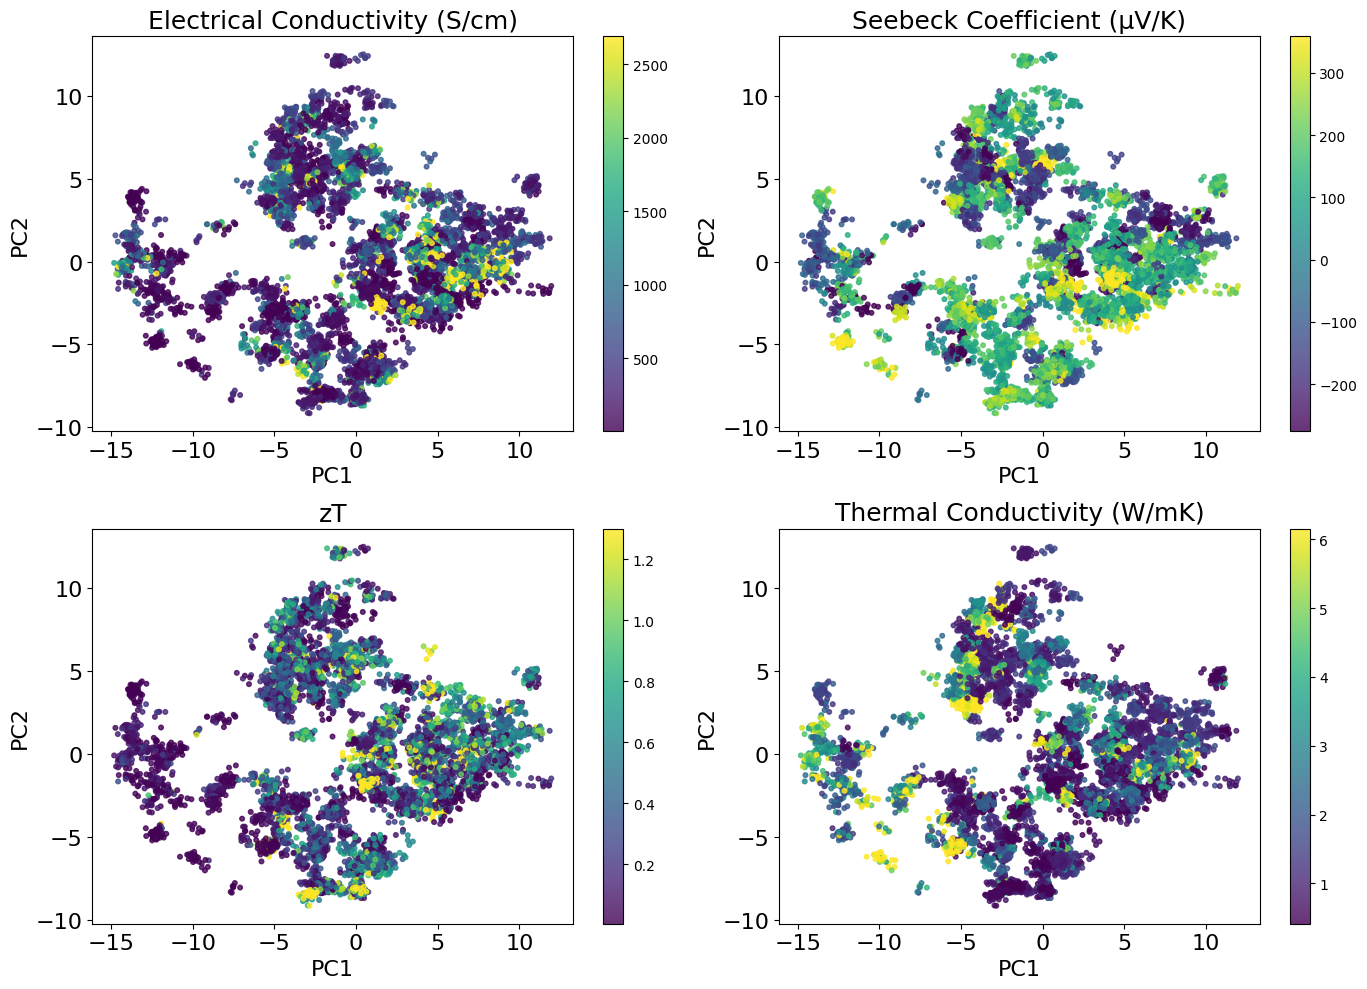

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ============================================================
# Load data
# ============================================================
file_path = r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\ThermoElectric_NEW\CLEANED_DATA.csv"
df = pd.read_csv(file_path)

base_path = r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\ThermoElectric_NEW"
# Clean columns
df.columns = (
    df.columns
    .str.strip()
    .str.replace("Âµ", "µ", regex=False)
    .str.replace("\xa0", " ", regex=False)
)

# Remove unnamed column
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

# Outcomes
outcomes = [
    "Electrical Conductivity (S/cm)",
    "Seebeck Coefficient (µV/K)",
    "zT",
    "Total Thermal Conductivity (W/mK)"
]

# ============================================================
# Features
# ============================================================
X = df.drop(columns=outcomes)
X = X.select_dtypes(include=[np.number])

# Remove NaNs
plot_df = pd.concat([X, df[outcomes]], axis=1).dropna().reset_index(drop=True)

X_clean = plot_df[X.columns]
Y_clean = plot_df[outcomes]

# ============================================================
# PCA
# ============================================================
X_scaled = StandardScaler().fit_transform(X_clean)
X_pca = PCA(n_components=2).fit_transform(X_scaled)

# ============================================================
# EXACT SAME JITTER AS YOUR SCRIPT
# ============================================================
JITTER_FRAC = 0.01
JITTER_RANDOM_STATE = 0

rng = np.random.default_rng(JITTER_RANDOM_STATE)

span_x = np.max(X_pca[:, 0]) - np.min(X_pca[:, 0])
scale_x = span_x * JITTER_FRAC if span_x > 0 else JITTER_FRAC
X_pca_j1 = X_pca[:, 0] + rng.normal(0.0, scale_x, size=len(X_pca))

span_y = np.max(X_pca[:, 1]) - np.min(X_pca[:, 1])
scale_y = span_y * JITTER_FRAC if span_y > 0 else JITTER_FRAC
X_pca_j2 = X_pca[:, 1] + rng.normal(0.0, scale_y, size=len(X_pca))

# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

titles = [
    "Electrical Conductivity (S/cm)",
    "Seebeck Coefficient (µV/K)",
    "zT",
    "Thermal Conductivity (W/mK)"
]

for i, outcome in enumerate(outcomes):
    ax = axes[i]
    y = Y_clean[outcome].values

    vmin = np.percentile(y, 5)
    vmax = np.percentile(y, 95)

    sc = ax.scatter(
        X_pca_j1,
        X_pca_j2,
        c=y,
        cmap="viridis",
        s=11,
        alpha=0.8,
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(titles[i], fontsize=18)
    ax.tick_params(axis="both", labelsize=16)  # increase to 18, 20, etc.
    ax.set_xlabel("PC1", fontsize=16)
    ax.set_ylabel("PC2", fontsize=16)

    plt.colorbar(sc, ax=ax)

plt.tight_layout()
out_path = os.path.join(base_path, "distribution_outcome_sysTEm.png")
plt.savefig(out_path, dpi=100, bbox_inches="tight")
plt.show()

C:\Users\rafae\AppData\Local\Temp\ipykernel_41164\2144625784.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.90, 0.95])


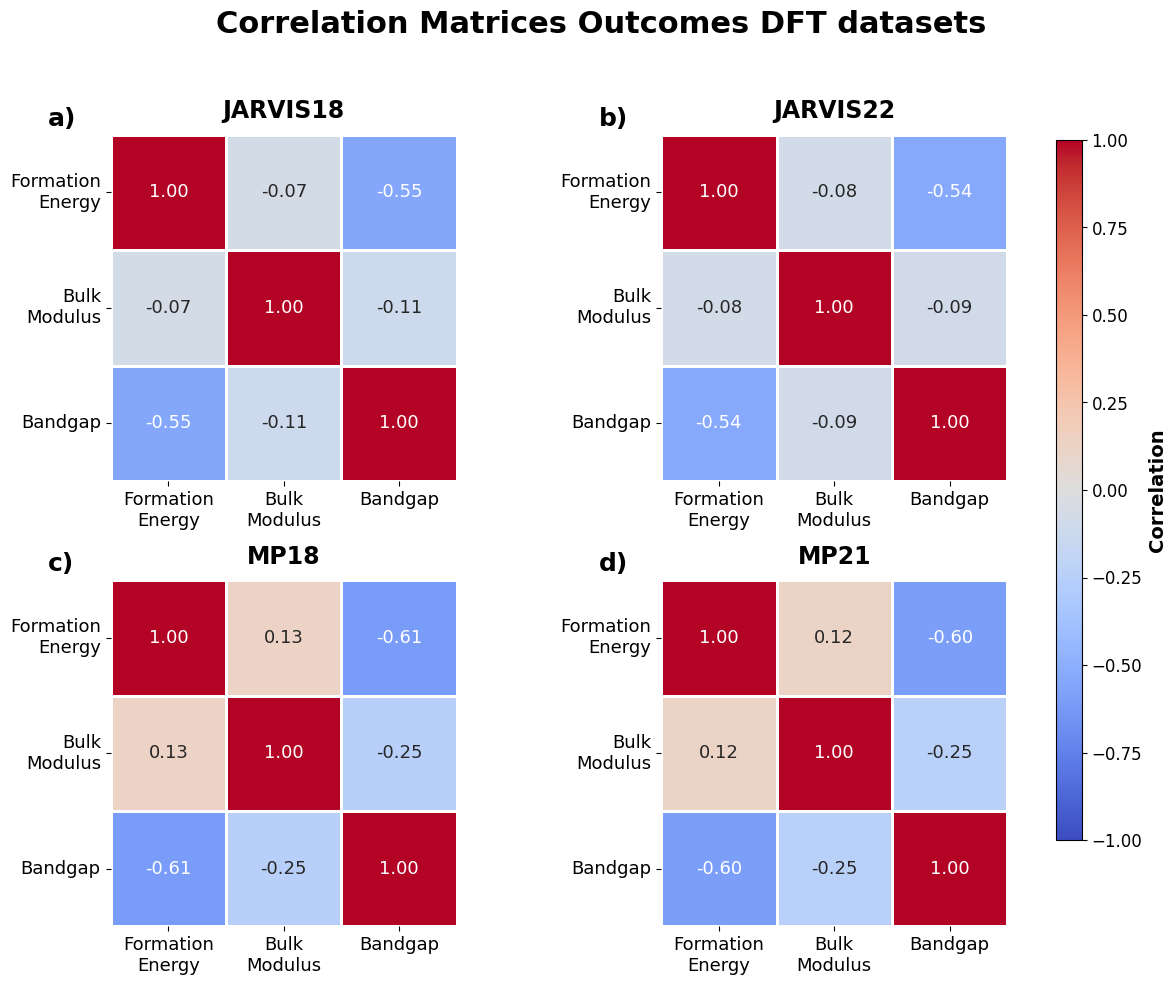

Saved figure to:
C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2\correlation_matrices_all_datasets.png


In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Path
# ============================================================
base_path = r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2"

files = {
    "JARVIS18": "alldata_jarvis18.csv",
    "JARVIS22": "alldata_jarvis22.csv",
    "MP18": "alldata_mp18.csv",
    "MP21": "alldata_mp21.csv",
}

# ============================================================
# Columns of interest
# ============================================================
cols = ["e_form", "bulk_modulus", "bandgap"]

pretty_labels = {
    "e_form": "Formation\nEnergy",
    "bulk_modulus": "Bulk\nModulus",
    "bandgap": "Bandgap",
}

# ============================================================
# Font sizes
# ============================================================
MAIN_TITLE_FONTSIZE = 22
SUBPLOT_TITLE_FONTSIZE = 17
TICK_LABEL_FONTSIZE = 13
ANNOT_FONTSIZE = 13
LETTER_FONTSIZE = 18
CBAR_LABEL_FONTSIZE = 14
CBAR_TICK_FONTSIZE = 12

# ============================================================
# Figure
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

letters = ["a)", "b)", "c)", "d)"]
last_im = None

# ============================================================
# Loop datasets
# ============================================================
for i, ((dataset_name, filename), ax) in enumerate(zip(files.items(), axes)):
    file_path = os.path.join(base_path, filename)

    df = pd.read_csv(file_path)

    # Select only required columns and drop NaNs
    df_sub = df[cols].dropna()

    # Correlation matrix
    corr = df_sub.corr()

    # Pretty labels
    corr.index = [pretty_labels[c] for c in corr.index]
    corr.columns = [pretty_labels[c] for c in corr.columns]

    # Heatmap
    hm = sns.heatmap(
        corr,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        square=True,
        cbar=False,
        linewidths=1.0,
        linecolor="white",
        annot_kws={"fontsize": ANNOT_FONTSIZE}
    )

    last_im = hm.collections[0]

    # Titles and ticks
    ax.set_title(dataset_name, fontsize=SUBPLOT_TITLE_FONTSIZE, fontweight="bold", pad=12)
    ax.tick_params(axis="x", labelsize=TICK_LABEL_FONTSIZE, rotation=0)
    ax.tick_params(axis="y", labelsize=TICK_LABEL_FONTSIZE, rotation=0)

    # Subplot letter
    ax.text(
        -0.18, 1.08, letters[i],
        transform=ax.transAxes,
        fontsize=LETTER_FONTSIZE,
        fontweight="bold",
        va="top",
        ha="left"
    )

# ============================================================
# Manual colorbar (no overlap)
# ============================================================
cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])  # [left, bottom, width, height]

cbar = fig.colorbar(last_im, cax=cbar_ax)
cbar.set_label("Correlation", fontsize=CBAR_LABEL_FONTSIZE, fontweight="bold")
cbar.ax.tick_params(labelsize=CBAR_TICK_FONTSIZE)

# ============================================================
# Main title
# ============================================================
fig.suptitle(
    "Correlation Matrices Outcomes DFT datasets",
    fontsize=MAIN_TITLE_FONTSIZE,
    fontweight="bold",
    y=0.98
)

# ============================================================
# Layout (reserve space for colorbar)
# ============================================================
plt.tight_layout(rect=[0, 0, 0.90, 0.95])

# ============================================================
# Save and show
# ============================================================
out_path = os.path.join(base_path, "correlation_matrices_all_datasets.png")
plt.savefig(out_path, dpi=100, bbox_inches="tight")
plt.show()

print(f"Saved figure to:\n{out_path}")

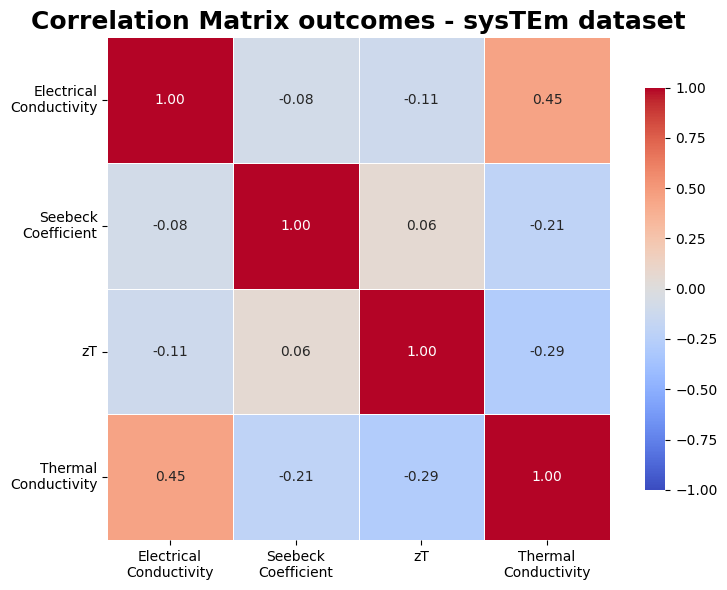

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# File path
# ============================================================
file_path = r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\ThermoElectric_NEW\CLEANED_DATA.csv"

# ============================================================
# Load CSV
# ============================================================
df = pd.read_csv(file_path, encoding='latin1')

# ============================================================
# Clean column names
# ============================================================
df = df.rename(columns={
    "Seebeck Coefficient (ÂµV/K)": "Seebeck Coefficient (µV/K)",
    "Total Thermal Conductivity (W/mK)": "Thermal Conductivity (W/mK)"
})

# ============================================================
# Select columns
# ============================================================
cols = [
    "Electrical Conductivity (S/cm)",
    "Seebeck Coefficient (µV/K)",
    "zT",
    "Thermal Conductivity (W/mK)"
]

df_selected = df[cols].dropna()

# ============================================================
# Correlation matrix
# ============================================================
corr_matrix = df_selected.corr()

# ============================================================
# Custom labels (split into two rows)
# ============================================================
labels = [
    "Electrical\nConductivity",
    "Seebeck\nCoefficient",
    "zT",
    "Thermal\nConductivity"
]

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

# Apply custom labels
ax.set_xticklabels(labels, rotation=0)
ax.set_yticklabels(labels, rotation=0)

plt.title("Correlation Matrix outcomes - sysTEm dataset", fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

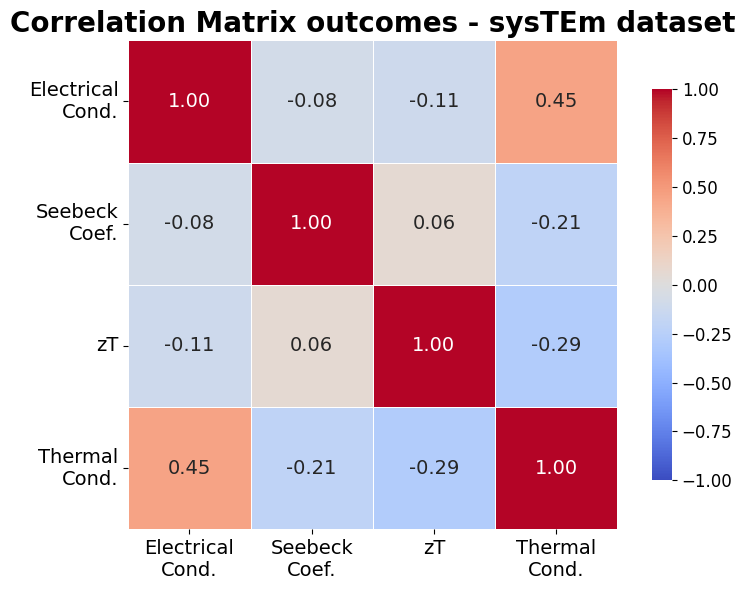

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# File path
# ============================================================
file_path = r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\ThermoElectric_NEW\CLEANED_DATA.csv"
base_path = r"C:\Users\rafae\OneDrive\Imágenes\Documentos\PhDToronto\OLD_FILES\PhD Toronto\DatasetGeneration\Better_Acqsition\NewAlg_DFT2"
# ============================================================
# Load CSV
# ============================================================
df = pd.read_csv(file_path, encoding='latin1')

# ============================================================
# Clean column names
# ============================================================
df = df.rename(columns={
    "Seebeck Coefficient (ÂµV/K)": "Seebeck Coefficient (µV/K)",
    "Total Thermal Conductivity (W/mK)": "Thermal Conductivity (W/mK)"
})

cols = [
    "Electrical Conductivity (S/cm)",
    "Seebeck Coefficient (µV/K)",
    "zT",
    "Thermal Conductivity (W/mK)"
]

df_selected = df[cols].dropna()
corr_matrix = df_selected.corr()

# ============================================================
# Labels (two lines)
# ============================================================
labels = [
    "Electrical\nCond.",
    "Seebeck\nCoef.",
    "zT",
    "Thermal\nCond."
]

# ============================================================
# FONT SIZES (adjust here)
# ============================================================
TITLE_SIZE = 20
TICK_SIZE = 14
ANNOT_SIZE = 14   # numbers inside heatmap
CBAR_SIZE = 12

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(8, 6))

ax = sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={"size": ANNOT_SIZE},   # ← numbers size
    cbar_kws={"shrink": 0.8}
)

# Axis tick labels
ax.set_xticklabels(labels, rotation=0, fontsize=TICK_SIZE)
ax.set_yticklabels(labels, rotation=0, fontsize=TICK_SIZE)

# Title
plt.title("Correlation Matrix outcomes - sysTEm dataset",
          fontsize=TITLE_SIZE, fontweight='bold')

# Colorbar font size
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=CBAR_SIZE)

plt.tight_layout()
out_path = os.path.join(base_path, "correlation_matrices_sysTEm.png")
plt.savefig(out_path, dpi=100, bbox_inches="tight")
plt.show()